In [17]:
import sys
sys.path.append("/home/dk5299/Projects_31926/RNA-seq/Kallies_Sci_Immuno_2025")
from src.paths import DATA_DIR, INTERMEDIATE_DIR, RESULTS_DIR

import scanpy as sc
import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt

sc.settings.verbosity = 3

In [18]:
input_file = INTERMEDIATE_DIR / "00_loaded_raw.h5ad"
adata = sc.read_h5ad(input_file)

adata

AnnData object with n_obs × n_vars = 14841 × 32288
    var: 'gene_ids', 'feature_types'

In [24]:
adata.var_names[adata.var_names.str.contains("HT|hashtag|TotalSeq", case=False, regex=True)]

Index(['Htr2b', 'Htr5b', 'Dhtkd1', 'Chtop', 'Phtf1os', 'Phtf1', 'Htr1d',
       'Htr6', 'Phtf2', 'Htr5a', 'Htt', 'Htra3', 'Htra2', 'Htatip2', 'Htra1',
       'Htra4', 'Chtf8', 'Htr3a', 'Htr3b', 'Htr1b', 'P4htm', 'Dbpht2', 'Htr1a',
       'Thtpa', 'Htr2a', 'Htr1f', 'Chtf18', 'Bvht', 'Htr4', 'Htr7', 'Shtn1',
       'Htatsf1', 'Htr2c', 'HT1', 'HT2', 'HT3'],
      dtype='object')

In [25]:
adata.var["feature_types"].value_counts()

feature_types
Gene Expression     32285
Antibody Capture        3
Name: count, dtype: int64

In [19]:
#Remove mt DNA genes 
adata.var["mt"] = adata.var_names.str.startswith("mt-")

In [20]:
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"], 
    inplace=True
)

In [21]:
adata.obs[[
    "n_genes_by_counts",
    "total_counts",
    "pct_counts_mt"
]].head()


,n_genes_by_counts,total_counts,pct_counts_mt
AAACCCAAGTCAAGCG-1,3272,15777.0,2.484629
AAACCCACAATAAGGT-1,1932,5833.0,2.571576
AAACCCACAGCCCACA-1,3324,17901.0,1.430088
AAACCCACATACTTTC-1,3150,18605.0,1.429723
AAACCCACATAGTCGT-1,3359,19578.0,1.292267


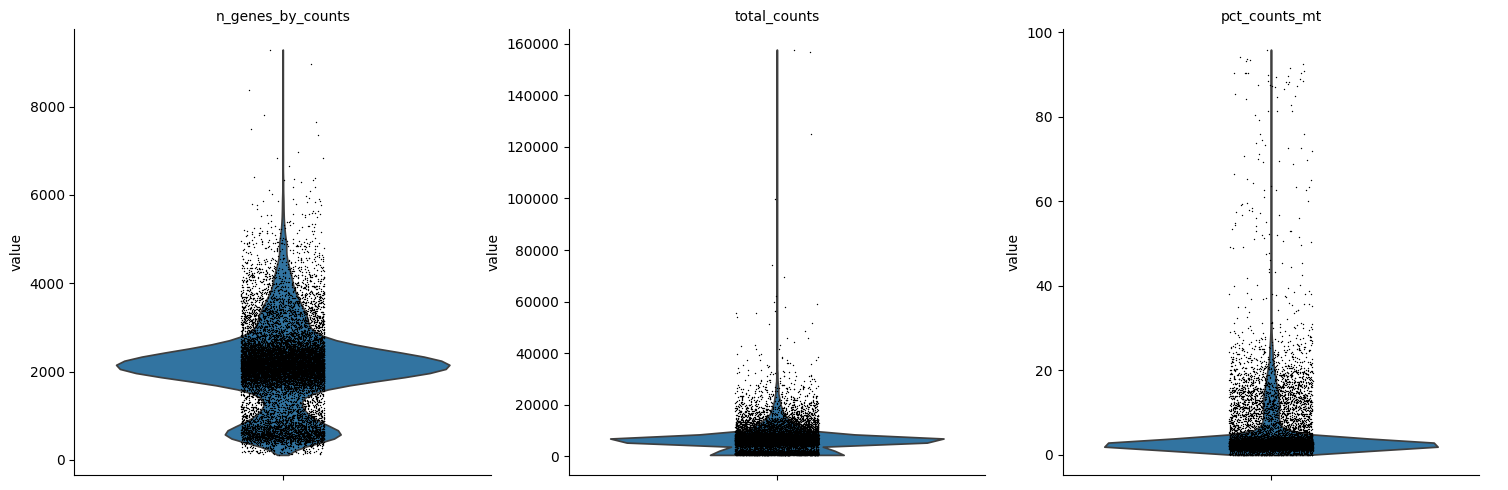

In [12]:
sc.pl.violin(
    adata,
    keys=["n_genes_by_counts", "total_counts", "pct_counts_mt"], 
    rotation=45, 
    multi_panel=True
)

In [13]:
min_genes = 200
max_genes = 6000
max_mt = 15
min_cells_per_gene = 3

In [15]:
print("Before filtering", adata.shape)

sc.pp.filter_cells(adata, min_genes = min_genes)
sc.pp.filter_genes(adata, min_cells=min_cells_per_gene)

adata = adata[adata.obs["n_genes_by_counts"] < max_genes].copy()
adata = adata[adata.obs["pct_counts_mt"] < max_mt].copy()

print("After filtering", adata.shape)

Before filtering (14841, 32285)
filtered out 49 cells that have less than 200 genes expressed
filtered out 16022 genes that are detected in less than 3 cells
After filtering (13857, 16263)


In [16]:
output_file = INTERMEDIATE_DIR / "01_filtered.h5ad"
adata.write_h5ad(output_file)
print("Saved:", output_file)


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/objects/01_filtered.h5ad
